## Personal notebook for decision tree by Marjaana Koski

### For this notebook the cleaned_100k.csv was used. The same skeleton from the main notebook was copied to ensure the same pipeline for the results comparison.

**Workflow**
**Workflow**
1. Importing needed libraries
2. Data reading and splitting (copied from main notebook)
3. Creating skeleton (copied from main notebook)
3.1. Decision tree with SMOTE + PCA + StandardScaler
3.2. Decision tree with no SMOTE + PCA + StandardScaler
3.3. Decision tree with SMOTE + PCA + no scaler
3.4. Decision tree with no SMOTE + PCA + no scaler
3.5. Decision tree with SMOTE + LDA + no scaler
3.6. Decision tree with no SMOTE + LDA + no scaler

### Imports

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                             ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import seaborn as sns
from sklearn.tree import export_graphviz
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree



### Reading sampled csv and splitting data 60/20/20

In [32]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


### Creating skeleton

In [34]:
# Agreed 10-feature list
# Lotan skeleton
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 3
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True, use_scaler=True, use_lda=False):

    steps = []

    # 1. scaling
    if use_scaler:
        steps.append(("scaler", StandardScaler()))

    # 2. SMOTE (vain train-dataan)
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42)))
    # 3.1 Use LDA 
    if use_lda:
        steps.append(("lda", LDA()))

    # 3.2 OR, use PCA (valinnainen)
    if use_pca:
        steps.append(("pca", PCA()))

    # 4. model
    steps.append(("clf", clf))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring=SCORING,
        n_jobs=N_JOBS,
        verbose=1
    )

    grid.fit(X_train_sel, y_train)

    y_val_pred = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{label} — Test Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params:", grid.best_params_)
    print(f"Validation acc: {val_acc:.4f}, f1: {val_f1:.4f}")
    print(f"Test acc: {test_acc:.4f}, f1: {test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label": label,
        "grid": grid,
        "best_params": grid.best_params_,
        "val_acc": val_acc,
        "val_f1_macro": val_f1,
        "test_acc": test_acc,
        "test_f1_macro": test_f1,
        "smote": use_smote,
        "pca": use_pca
    }

all_results = []

## DT with PCA, standard scaler, an with and without SMOTE

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


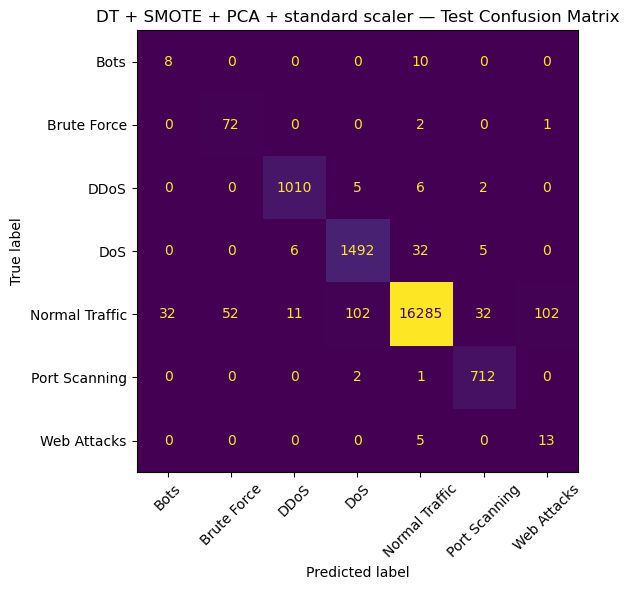


=== DT + SMOTE + PCA + standard scaler ===
Best params: {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'pca__n_components': 8}
Validation acc: 0.9793, f1: 0.7333
Test acc: 0.9796, f1: 0.7271
                precision    recall  f1-score   support

          Bots      0.200     0.444     0.276        18
   Brute Force      0.581     0.960     0.724        75
          DDoS      0.983     0.987     0.985      1023
           DoS      0.932     0.972     0.952      1535
Normal Traffic      0.997     0.980     0.988     16616
 Port Scanning      0.948     0.996     0.971       715
   Web Attacks      0.112     0.722     0.194        18

      accuracy                          0.980     20000
     macro avg      0.679     0.866     0.727     20000
  weighted avg      0.986     0.980     0.982     20000

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


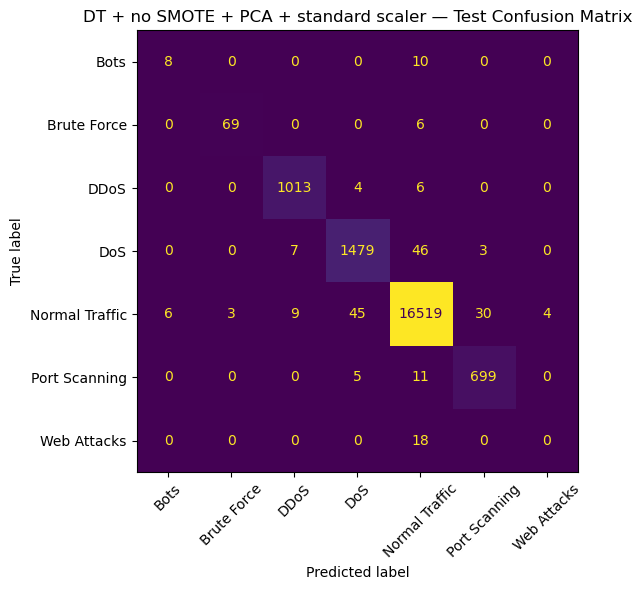


=== DT + no SMOTE + PCA + standard scaler ===
Best params: {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'pca__n_components': 6}
Validation acc: 0.9893, f1: 0.7767
Test acc: 0.9893, f1: 0.7644
                precision    recall  f1-score   support

          Bots      0.571     0.444     0.500        18
   Brute Force      0.958     0.920     0.939        75
          DDoS      0.984     0.990     0.987      1023
           DoS      0.965     0.964     0.964      1535
Normal Traffic      0.994     0.994     0.994     16616
 Port Scanning      0.955     0.978     0.966       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.989     20000
     macro avg      0.775     0.756     0.764     20000
  weighted avg      0.989     0.989     0.989     20000



In [ ]:
dt_grid = {
    "pca__n_components":      [4, 6, 8],
    "clf__criterion":         ["gini", "entropy"],
    "clf__max_depth":         [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf":  [1, 2, 4],
    "clf__class_weight":      [None, "balanced"],
}

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42), dt_grid,
                   label="3.1. DT with SMOTE + PCA + StandardScaler", use_pca=True, use_smote=True, use_scaler=True)
)

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42), dt_grid,
                   label="3.2. DT with no SMOTE + PCA + StandardScaler", use_pca=True, use_smote=False,use_scaler=True)
)

## DT with PCA, without scaler and with and without SMOTE

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


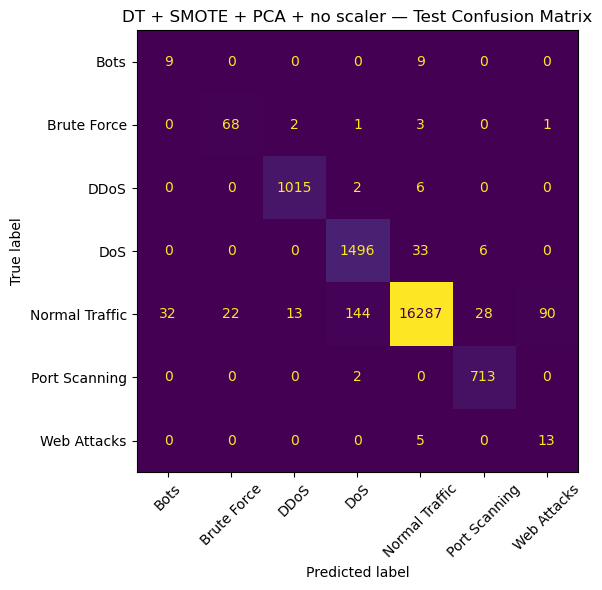


=== DT + SMOTE + PCA + no scaler ===
Best params: {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'pca__n_components': 8}
Validation acc: 0.9797, f1: 0.7499
Test acc: 0.9800, f1: 0.7480
                precision    recall  f1-score   support

          Bots      0.220     0.500     0.305        18
   Brute Force      0.756     0.907     0.824        75
          DDoS      0.985     0.992     0.989      1023
           DoS      0.909     0.975     0.941      1535
Normal Traffic      0.997     0.980     0.988     16616
 Port Scanning      0.954     0.997     0.975       715
   Web Attacks      0.125     0.722     0.213        18

      accuracy                          0.980     20000
     macro avg      0.707     0.868     0.748     20000
  weighted avg      0.985     0.980     0.982     20000

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


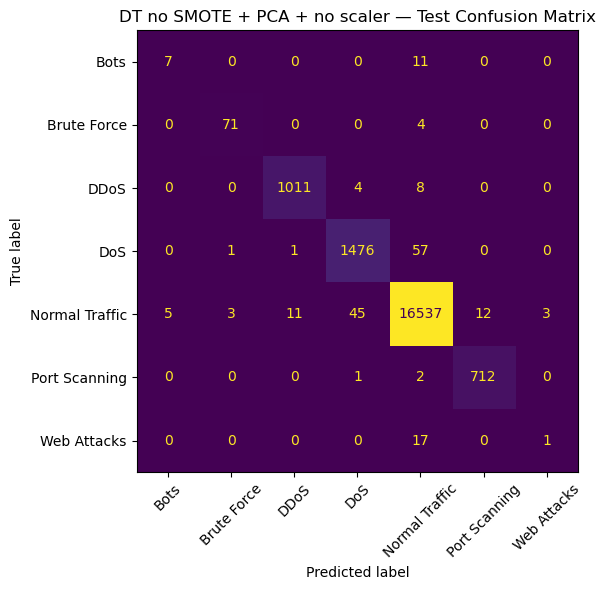


=== DT no SMOTE + PCA + no scaler ===
Best params: {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'pca__n_components': 8}
Validation acc: 0.9902, f1: 0.7763
Test acc: 0.9908, f1: 0.7773
                precision    recall  f1-score   support

          Bots      0.583     0.389     0.467        18
   Brute Force      0.947     0.947     0.947        75
          DDoS      0.988     0.988     0.988      1023
           DoS      0.967     0.962     0.964      1535
Normal Traffic      0.994     0.995     0.995     16616
 Port Scanning      0.983     0.996     0.990       715
   Web Attacks      0.250     0.056     0.091        18

      accuracy                          0.991     20000
     macro avg      0.816     0.762     0.777     20000
  weighted avg      0.990     0.991     0.990     20000



In [ ]:
dt_grid = {
    "pca__n_components":      [4, 6, 8],
    "clf__criterion":         ["gini", "entropy"],
    "clf__max_depth":         [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf":  [1, 2, 4],
    "clf__class_weight":      [None, "balanced"],
}

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42), dt_grid,
                   label="3.3. DT with SMOTE + PCA + no scaler", use_pca=True, use_smote=True, use_scaler=False)
)

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42), dt_grid,
                   label="3.4 DT with no SMOTE + PCA + no scaler", use_pca=True, use_smote=False, use_scaler=False)
)

## DT with LDA, no scaler, and with and without SMOTE

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


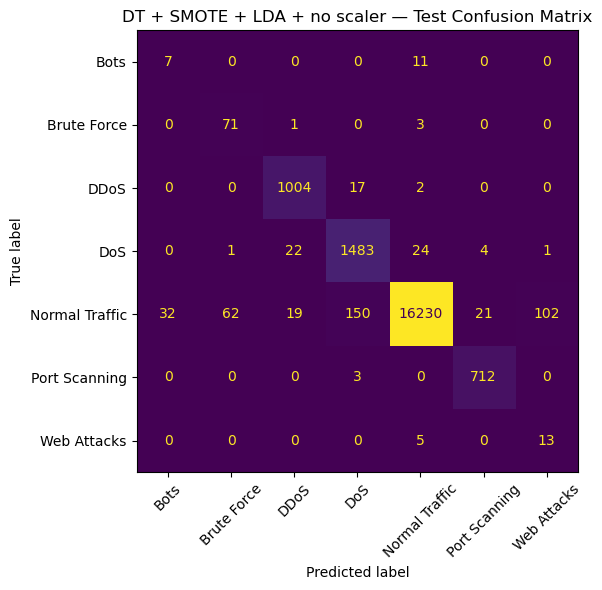


=== DT + SMOTE + LDA + no scaler ===
Best params: {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'lda__n_components': 6}
Validation acc: 0.9751, f1: 0.7235
Test acc: 0.9760, f1: 0.7125
                precision    recall  f1-score   support

          Bots      0.179     0.389     0.246        18
   Brute Force      0.530     0.947     0.679        75
          DDoS      0.960     0.981     0.971      1023
           DoS      0.897     0.966     0.930      1535
Normal Traffic      0.997     0.977     0.987     16616
 Port Scanning      0.966     0.996     0.981       715
   Web Attacks      0.112     0.722     0.194        18

      accuracy                          0.976     20000
     macro avg      0.663     0.854     0.713     20000
  weighted avg      0.983     0.976     0.979     20000

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


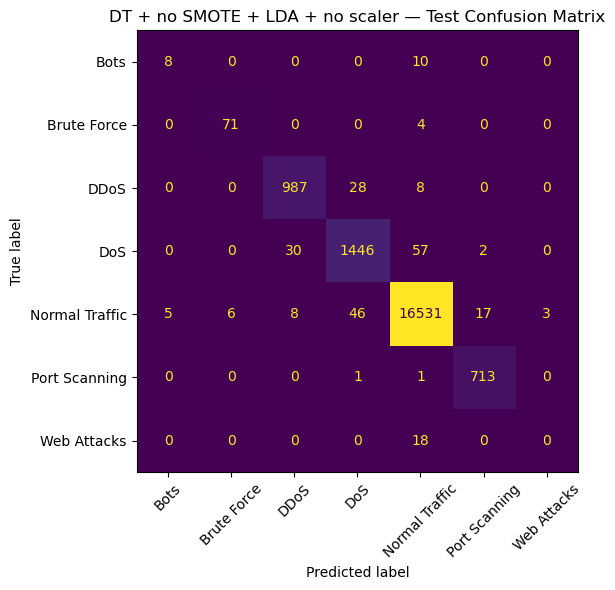


=== DT + no SMOTE + LDA + no scaler ===
Best params: {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'lda__n_components': 6}
Validation acc: 0.9880, f1: 0.7667
Test acc: 0.9878, f1: 0.7629
                precision    recall  f1-score   support

          Bots      0.615     0.444     0.516        18
   Brute Force      0.922     0.947     0.934        75
          DDoS      0.963     0.965     0.964      1023
           DoS      0.951     0.942     0.946      1535
Normal Traffic      0.994     0.995     0.994     16616
 Port Scanning      0.974     0.997     0.985       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.988     20000
     macro avg      0.774     0.756     0.763     20000
  weighted avg      0.987     0.988     0.987     20000



In [ ]:
dt_grid_lda = {
    "lda__n_components":      [3, 4, 6],
    "clf__criterion":         ["gini", "entropy"],
    "clf__max_depth":         [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf":  [1, 2, 4],
    "clf__class_weight":      [None, "balanced"],
}

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42), dt_grid_lda,
                   label="3.5. DT with SMOTE + LDA + no scaler", use_pca=False, use_smote=True, use_scaler=False, use_lda=True)
)

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42), dt_grid_lda,
                   label="3.6. DT with no SMOTE + LDA + no scaler", use_pca=False, use_smote=False, use_scaler=False, use_lda=True)
)

## DT without PCA, scaler, DTA, or SMOTE

Fitting 3 folds for each of 144 candidates, totalling 432 fits


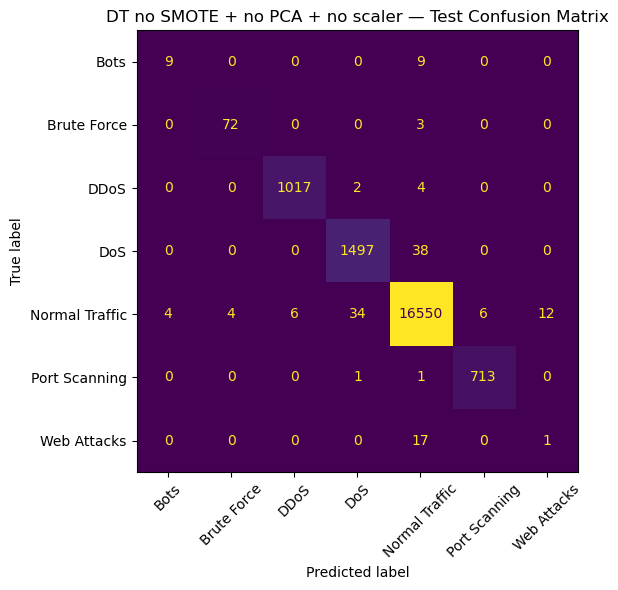


=== DT no SMOTE + no PCA + no scaler ===
Best params: {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5}
Validation acc: 0.9934, f1: 0.7944
Test acc: 0.9929, f1: 0.7941
                precision    recall  f1-score   support

          Bots      0.692     0.500     0.581        18
   Brute Force      0.947     0.960     0.954        75
          DDoS      0.994     0.994     0.994      1023
           DoS      0.976     0.975     0.976      1535
Normal Traffic      0.996     0.996     0.996     16616
 Port Scanning      0.992     0.997     0.994       715
   Web Attacks      0.077     0.056     0.065        18

      accuracy                          0.993     20000
     macro avg      0.811     0.783     0.794     20000
  weighted avg      0.993     0.993     0.993     20000



In [ ]:
dt_grid_nopca = {
    "clf__criterion":         ["gini", "entropy"],
    "clf__max_depth":         [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf":  [1, 2, 4],
    "clf__class_weight":      [None, "balanced"],
}

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42), dt_grid_nopca,
                   label="3.7. DT with no SMOTE + no PCA + no scaler", 
                   use_pca=False, use_smote=False, use_scaler=False)
)

## Summarize results

In [58]:
for a in all_results:
    print(f"\n{a['label']}")
    print(f"  Best params : {a['best_params']}")
    print(f"  Val  f1_macro: {a['val_f1_macro']:.4f}")
    print(f"  Test f1_macro: {a['test_f1_macro']:.4f}")


DT + SMOTE + PCA + standard scaler
  Best params : {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'pca__n_components': 8}
  Val  f1_macro: 0.7333
  Test f1_macro: 0.7271

DT + no SMOTE + PCA + standard scaler
  Best params : {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'pca__n_components': 6}
  Val  f1_macro: 0.7767
  Test f1_macro: 0.7644

DT + SMOTE + PCA + no scaler
  Best params : {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'pca__n_components': 8}
  Val  f1_macro: 0.7499
  Test f1_macro: 0.7480

DT + SMOTE + PCA + no scaler
  Best params : {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'pca__n_components': 8}
  Val  f1_macr

In [60]:
best_result = max(all_results, key=lambda x: x['test_f1_macro'])
print(f"Best model: {best_result['label']}")

if "pca" in best_result["grid"].best_estimator_.named_steps:
    pca = best_result["grid"].best_estimator_.named_steps["pca"]
    components_df_PCA = pd.DataFrame(
        pca.components_,
        columns=FEATURES,
        index=[f"PCA_{i}" for i in range(pca.n_components_)]
    )
    print(components_df_PCA.round(3))
else:
    print("Best model does not use PCA — showing PCA weights from best PCA model instead")
    # get best PCA model specifically
    pca_results = [r for r in all_results if r['pca']]
    best_pca = max(pca_results, key=lambda x: x['test_f1_macro'])
    pca = best_pca["grid"].best_estimator_.named_steps["pca"]
    components_df_PCA = pd.DataFrame(
        pca.components_,
        columns=FEATURES,
        index=[f"PCA_{i}" for i in range(pca.n_components_)]
    )
    print(components_df_PCA.round(3))

Best model: DT no SMOTE + no PCA + no scaler
Best model does not use PCA — showing PCA weights from best PCA model instead
       Flow Duration  Total Fwd Packets  Total Length of Fwd Packets  \
PCA_0          0.999              0.000                        0.000   
PCA_1          0.032              0.000                        0.000   
PCA_2          0.001             -0.000                       -0.000   
PCA_3         -0.000              0.130                        0.992   
PCA_4          0.000              0.062                       -0.004   
PCA_5         -0.000             -0.978                        0.127   
PCA_6         -0.000             -0.150                        0.025   
PCA_7         -0.000             -0.035                        0.007   

       Flow Bytes/s  Flow Packets/s  Fwd Packet Length Mean  \
PCA_0        -0.032          -0.001                   0.000   
PCA_1         0.999           0.002                   0.000   
PCA_2        -0.002           1.000    

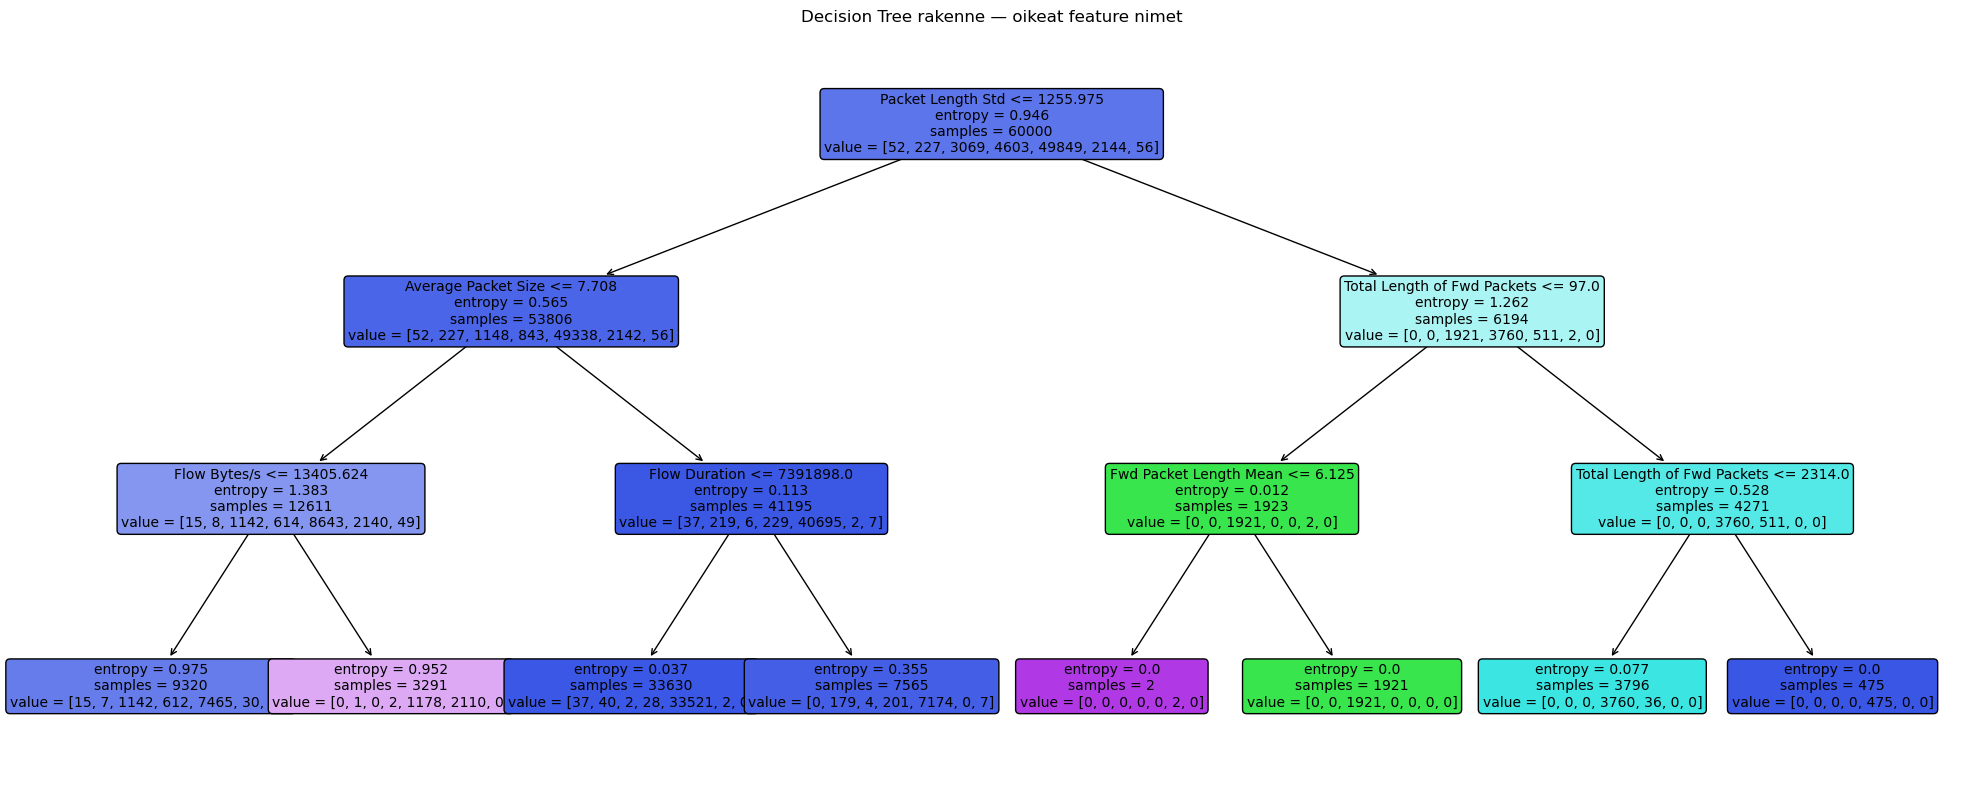

In [56]:
from sklearn.tree import plot_tree, DecisionTreeClassifier

dt_viz = DecisionTreeClassifier(random_state=42,criterion='entropy',
    max_depth = 3,
    min_samples_split =5,
    min_samples_leaf = 1,
    class_weight = None)
dt_viz.fit(X_train_sel, y_train)

plt.figure(figsize=(20, 8))
plot_tree(dt_viz,
          max_depth=3,
          feature_names=FEATURES,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree rakenne — oikeat feature nimet")
plt.tight_layout()
plt.show()

### Running the model without SMOTE and scaling

### Creating confusion matrix without SMOTE and scaling

### Running the model with SMOTE, PCA, and weighing

In this part the model uses previously created method